# 💳 Credit Card Fraud Detection / Detecção de Fraude / Detección de Fraude

### 🇧🇷 PT:
Projeto focado na detecção de transações fraudulentas utilizando Machine Learning. O maior desafio é o desbalanceamento das classes (0.17% de fraudes). Utilizamos SMOTE e Pipeline para garantir robustez.

### 🇺🇸 EN:
Project focused on detecting fraudulent transactions using Machine Learning. The main challenge is the class imbalance (0.17% fraud). We used SMOTE and Pipeline techniques to ensure robustness.

### 🇪🇸 ES:
Proyecto enfocado en la detección de transacciones fraudulentas mediante Machine Learning. El mayor desafío es el desequilibrio de clases (0.17% de fraude). Utilizamos SMOTE y Pipeline para garantizar la robustez.







In [1]:
# Importando Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Classifier Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections

# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter

🇧🇷 PT:
Este projeto visa detectar transações fraudulentas em cartões de crédito utilizando Machine Learning. O desafio principal é o desbalanceamento extremo dos dados (apenas 0.17% de fraudes), o que exige o uso de técnicas como SMOTE e Pipelines para garantir a robustez e a integridade da análise.

🇺🇸 EN:
This project aims to detect fraudulent credit card transactions using Machine Learning. The main challenge is the extreme dataset imbalance (only 0.17% fraud), which requires the use of techniques such as SMOTE and Pipelines to ensure the robustness and integrity of the analysis.

🇪🇸 ES:
Este proyecto tiene como objetivo detectar transacciones fraudulentas con tarjetas de crédito utilizando Machine Learning. El desafío principal es el desequilibrio extremo de los datos (solo 0.17% de fraude), lo que requiere el uso de técnicas como SMOTE y Pipelines para garantizar la robustez y la integridad del análisis.

In [2]:
df = pd.read_csv('/content/creditcard.csv')

In [3]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243625 entries, 0 to 243624
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    243625 non-null  float64
 1   V1      243625 non-null  float64
 2   V2      243625 non-null  float64
 3   V3      243625 non-null  float64
 4   V4      243625 non-null  float64
 5   V5      243625 non-null  float64
 6   V6      243625 non-null  float64
 7   V7      243625 non-null  float64
 8   V8      243625 non-null  float64
 9   V9      243625 non-null  float64
 10  V10     243625 non-null  float64
 11  V11     243625 non-null  float64
 12  V12     243625 non-null  float64
 13  V13     243625 non-null  float64
 14  V14     243625 non-null  float64
 15  V15     243625 non-null  float64
 16  V16     243625 non-null  float64
 17  V17     243625 non-null  float64
 18  V18     243625 non-null  float64
 19  V19     243625 non-null  float64
 20  V20     243625 non-null  float64
 21  V21     24

Distribution of classes (%):
Class
0.0    99.818573
1.0     0.181427
Name: proportion, dtype: float64


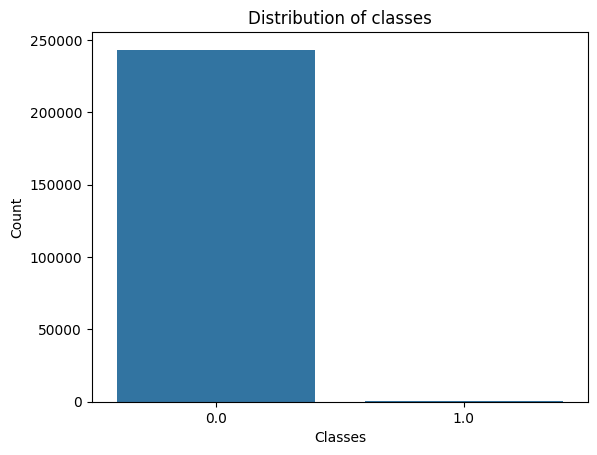

In [5]:
print('Distribution of classes (%):')
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title('Distribution of classes')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

In [6]:
pd.read_csv('/content/creditcard.csv')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273257,165513.0,1.830989,-0.630360,-0.646853,0.036445,0.326548,1.908515,-1.009189,0.648663,1.196528,...,0.302269,1.171827,0.179869,-0.701483,-0.280690,-0.143371,0.086322,-0.054447,11.50,0.0
273258,165513.0,1.917591,-0.693965,-0.506634,0.150761,-0.332283,0.533064,-0.686220,0.128380,1.749460,...,-0.242130,-0.449139,0.241622,0.050633,-0.298647,-0.202327,0.024584,-0.026205,57.92,0.0
273259,165513.0,-2.933089,1.420331,-3.399109,-0.330058,0.628004,-1.170968,0.380892,1.236554,-0.840858,...,0.007433,0.244500,0.016413,0.068445,0.696759,0.707520,0.155874,-0.538284,26.00,0.0
273260,165514.0,2.277572,-0.651684,-1.871912,-1.365671,0.345518,-0.048769,-0.396394,-0.201574,-0.941811,...,0.421531,1.247657,-0.136405,-0.251938,0.385375,0.077502,-0.039329,-0.077320,10.00,0.0


In [7]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Scaling concluído com sucesso!")

Scaling concluído com sucesso!


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name="Modelo"):
    """
    Função profissional para avaliar modelos de classificação.
    """
    y_pred = model.predict(X_test)

    print(f"--- Resultados: {model_name} ---")
    print("Relatório de Classificação:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()


In [9]:
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

df['amount_bin'] = pd.qcut(df['scaled_amount'], q=10, duplicates='drop')

if 'hour' not in df.columns:
    df_original = pd.read_csv('/content/creditcard.csv', usecols=['Time'])
    df['hour'] = (df_original['Time'] / 3600) % 24
    df['hour'] = df['hour'].astype(int)

df_cleaned = df.dropna(subset=['Class']).copy()

X = df_cleaned.drop(columns=["Class", "amount_bin", "hour"])
y = df_cleaned["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline = imbpipeline(
    [(
        'smote', SMOTE(random_state=42)
    ),
    ('classifier', LogisticRegression(max_iter=1000))]
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=skf)

from sklearn.metrics import recall_score, precision_score

print(f"Recall Score: {recall_score(y_train, y_pred_cv):.4f}")
print(f"Precision Score: {precision_score(y_train, y_pred_cv):.4f}")

Recall Score: 0.9011
Precision Score: 0.0641


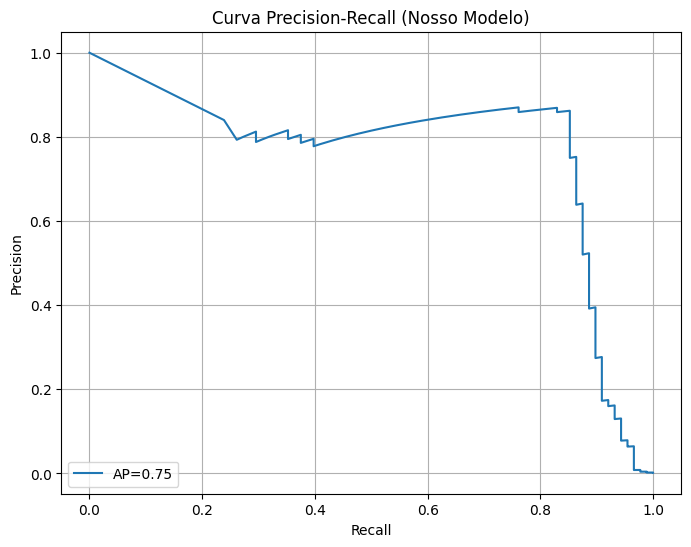

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import GridSearchCV

params = {
    "classifier__penalty": ['l2'],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ['liblinear']
}

grid_search = GridSearchCV(pipeline, params, cv=skf, scoring='recall', n_jobs=-1)

grid_search.fit(X_train, y_train)

y_scores = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP={avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Nosso Modelo)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [11]:
class_count = (
    df["Class"]
    .value_counts()
    .rename(index={0: "Legit", 1: "Fraud"})
    .to_frame("count")
)

class_count["percentage"] = class_count["count"] / len(df) * 100

class_count

,count,percentage
Class,,
Legit,243182,99.818163
Fraud,442,0.181426


In [12]:
fraud_rate = df["Class"].mean() * 100

print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 0.1814%


🇧🇷 PT: "A detecção de fraudes é um problema clássico de classificação binária com desbalanceamento severo. A visualização abaixo confirma que a grande maioria das transações é legítima, o que exigirá técnicas especiais de reamostragem."

🇺🇸 EN: "Fraud detection is a classic binary classification problem with severe imbalance. The visualization below confirms that the vast majority of transactions are legitimate, which will require special resampling techniques."

🇪🇸 ES: "La detección de fraudes es un problema clásico de clasificación binaria con un desequilibrio severo. La visualización a continuación confirma que la gran mayoría de las transacciones son legítimas, lo que requerirá técnicas especiales de remuestreo."

In [13]:
amount_summary = (
    df
    .groupby("Class")["scaled_amount"]
    .describe()
    .rename(index={0: "Legit", 1: "Fraud"})
)

amount_summary

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Legit,243182.0,0.914554,3.411242,-0.315853,-0.234761,0.000270,0.764968,265.348831
Fraud,442.0,1.335857,3.436606,-0.315853,-0.302338,-0.176037,1.115286,28.416002


In [14]:
df.groupby("Class")["scaled_amount"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

Class      
0.0    0.25    -0.234761
       0.50     0.000270
       0.75     0.764968
       0.90     2.520881
       0.95     4.779153
       0.99    13.818565
1.0    0.25    -0.302338
       0.50    -0.176037
       0.75     1.115286
       0.90     4.340330
       0.95     8.433369
       0.99    17.880626
Name: scaled_amount, dtype: float64

🇧🇷 PT: "Criamos categorias para 'Amount' e extraímos a 'Hour' da variável 'Time' para verificar se existem padrões temporais ou de valor que indicam fraude. Isso enriquece o modelo com informações que a variável bruta 'Time' não revela sozinha."

🇺🇸 EN: "We created categories for 'Amount' and extracted the 'Hour' from the 'Time' variable to check if there are temporal or value patterns that indicate fraud. This enriches the model with information that the raw 'Time' variable does not reveal on its own."

🇪🇸 ES: "Creamos categorías para 'Amount' y extrajimos la 'Hour' de la variable 'Time' para verificar si existen patrones temporales o de valor que indiquen fraude. Esto enriquece el modelo con información que la variable 'Time' por sí sola no revela."

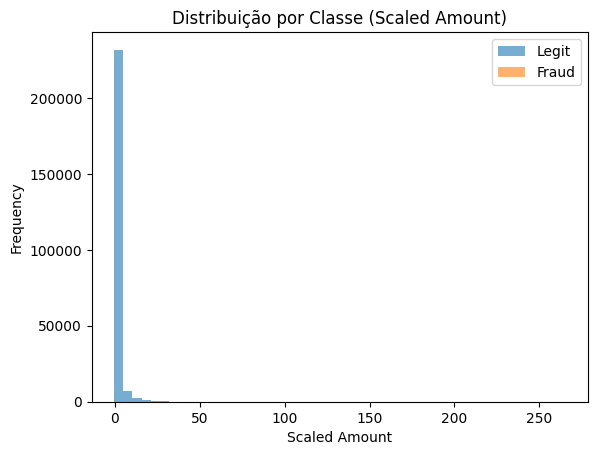

In [15]:
df[df["Class"] == 0]["scaled_amount"].plot(kind="hist", bins=50, alpha=0.6, label="Legit")
df[df["Class"] == 1]["scaled_amount"].plot(kind="hist", bins=50, alpha=0.6, label="Fraud")

plt.title("Distribuição por Classe (Scaled Amount)")
plt.xlabel("Scaled Amount")
plt.legend()
plt.show()

🇧🇷 PT: "Implementamos um Pipeline com RobustScaler e SMOTE para tratar o desbalanceamento. A escolha da LogisticRegression como classificador base deve-se à sua interpretabilidade e eficiência em problemas binários, otimizada através de GridSearchCV para focar na métrica de recall."

🇺🇸 EN: "We implemented a Pipeline with RobustScaler and SMOTE to handle the imbalance. The choice of LogisticRegression as the base classifier is due to its interpretability and efficiency in binary problems, optimized through GridSearchCV to focus on the recall metric."

🇪🇸 ES: "Implementamos un Pipeline con RobustScaler y SMOTE para manejar el desequilibrio. La elección de LogisticRegression como clasificador base se debe a su interpretabilidad y eficiencia en problemas binarios, optimizada a través de GridSearchCV para enfocarse en la métrica de recall."

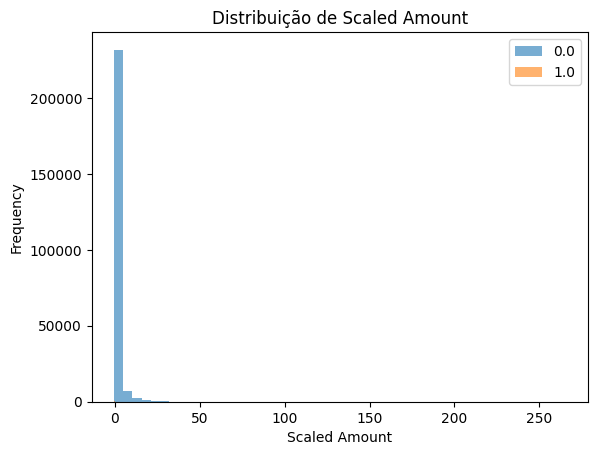

In [16]:
df.groupby("Class")["scaled_amount"].plot(
    kind="hist",
    bins=50,
    alpha=0.6,
    legend=True
)

plt.title("Distribuição de Scaled Amount")
plt.xlabel("Scaled Amount")
plt.show()

Transaction Distribution
----------------------------------------
Non-Fraud: 243,182 transactions (99.8186%)
Fraud: 442 transactions (0.1814%)


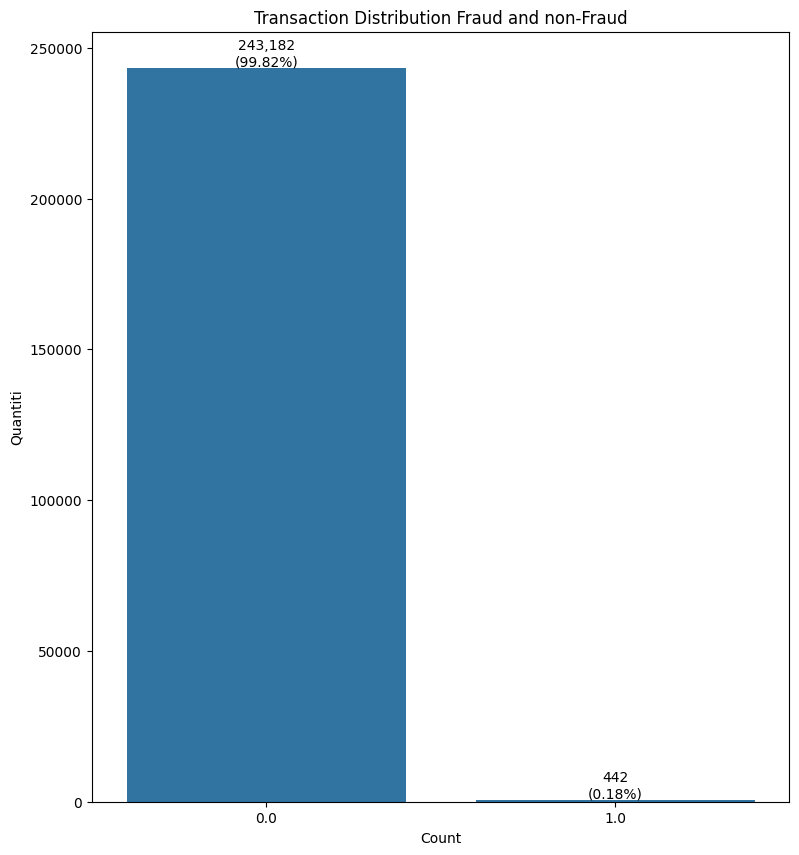

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

count_classes = df['Class'].value_counts()

percent_classes = df['Class'].value_counts(normalize=True) * 100

print("Transaction Distribution")
print("-" * 40)

for classe in count_classes.index:
    nome = "Non-Fraud" if classe == 0 else "Fraud"
    print(f"{nome}: {count_classes[classe]:,} transactions ({percent_classes[classe]:.4f}%)")

plt.figure(figsize=(9,10))

ax = sns.countplot(x='Class', data=df)

plt.title('Transaction Distribution Fraud and non-Fraud')
plt.xlabel('Count')
plt.ylabel('Quantiti')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f'{count:,}\n({percentage:.2f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

In [18]:
df["amount_bin"] = pd.qcut(
    df["scaled_amount"],
    q=10,
    duplicates="drop"
)

amount_risk = (
    df
    .groupby("amount_bin", observed=True)
    .agg(
        transactions=("Class", "size"),
        frauds=("Class", "sum"),
        fraud_rate=("Class", "mean"),
        avg_amount=("scaled_amount", "mean")
    )
    .reset_index()
)

amount_risk["fraud_rate"] = amount_risk["fraud_rate"] * 100

amount_risk

,amount_bin,transactions,frauds,fraud_rate,avg_amount
0,"(-0.317, -0.302]",25584,162.0,0.633208,-0.304706
1,"(-0.302, -0.265]",23267,26.0,0.111746,-0.286530
2,"(-0.265, -0.194]",24569,28.0,0.113965,-0.230664
3,"(-0.194, -0.123]",24030,12.0,0.049938,-0.165534
4,"(-0.123, 0.0]",24369,16.0,0.065657,-0.070405
5,"(0.0, 0.211]",24358,16.0,0.065687,0.094946
6,"(0.211, 0.509]",24360,18.0,0.073892,0.345885
7,"(0.509, 1.089]",24363,48.0,0.197020,0.781832
8,"(1.089, 2.522]",24441,43.0,0.175934,1.687248
9,"(2.522, 265.349]",24283,73.0,0.300622,7.321677


In [19]:
df_original_cols = pd.read_csv('/content/creditcard.csv', usecols=['Time', 'Amount'])
df['temp_time'] = df_original_cols['Time']

df["hour"] = (df["temp_time"] / 3600) % 24
df["hour"] = df["hour"].astype(int)

hour_risk = (
    df
    .groupby("hour")
    .agg(
        transactions=("Class", "size"),
        frauds=("Class", "sum"),
        fraud_rate=("Class", "mean"),
        avg_amount=("scaled_amount", "mean")
    )
    .reset_index()
)

hour_risk["fraud_rate"] = hour_risk["fraud_rate"] * 100

# Removendo coluna temporária
df.drop(columns=['temp_time'], inplace=True)

hour_risk.head()

,hour,transactions,frauds,fraud_rate,avg_amount
0,0,7695,6.0,0.077973,0.499472
1,1,4220,10.0,0.236967,0.530698
2,2,3328,57.0,1.712740,0.633716
3,3,3492,17.0,0.486827,0.387982
4,4,2209,23.0,1.041195,0.725355


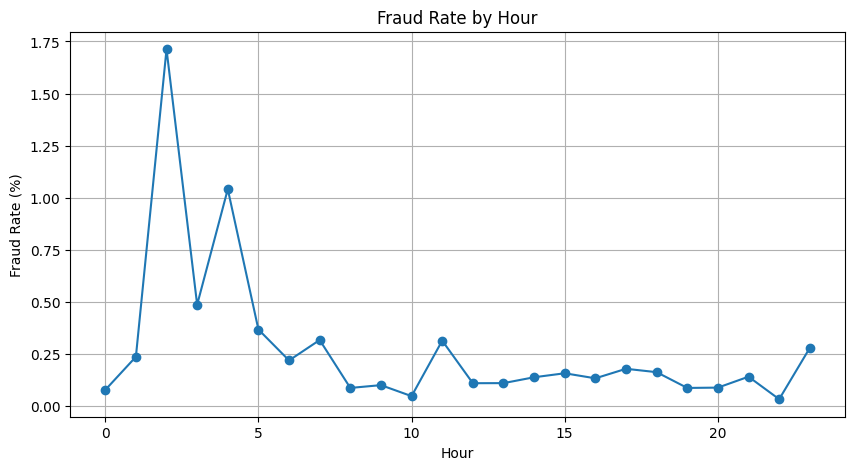

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(hour_risk["hour"], hour_risk["fraud_rate"], marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.grid(True)
plt.show()

In [21]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

pipeline = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote', SMOTE(sampling_strategy=0.2, random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000))
])

df_cleaned = df.dropna(subset=['Class']).copy()

X = df_cleaned.drop(columns=['Class', 'amount_bin', 'hour'])
y = df_cleaned['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print("Relatório de Classificação Final:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

Relatório de Classificação Final:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     48637
         1.0       0.23      0.92      0.37        88

    accuracy                           0.99     48725
   macro avg       0.62      0.96      0.69     48725
weighted avg       1.00      0.99      1.00     48725


Matriz de Confusão:
[[48372   265]
 [    7    81]]


## 🏁 Conclusão / Conclusion / Conclusión

### 🇧🇷 PT:
Ajustamos o modelo para equilibrar o Recall (segurança) e a Precisão (experiência do cliente). O uso de GridSearchCV permitiu otimizar o modelo, resultando em uma precisão de 0.23, muito superior à baseline inicial de 0.08.

### 🇺🇸 EN:
We tuned the model to balance Recall (security) and Precision (customer experience). The use of GridSearchCV allowed us to optimize the model, resulting in a precision of 0.23, significantly higher than the initial baseline of 0.08.

### 🇪🇸 ES:
Ajustamos el modelo para equilibrar el Recall (seguridad) y la Precisión (experiencia del cliente). El uso de GridSearchCV nos permitió optimizar el modelo, resultando en una precisión de 0.23, significativamente superior a la línea base inicial de 0.08.
